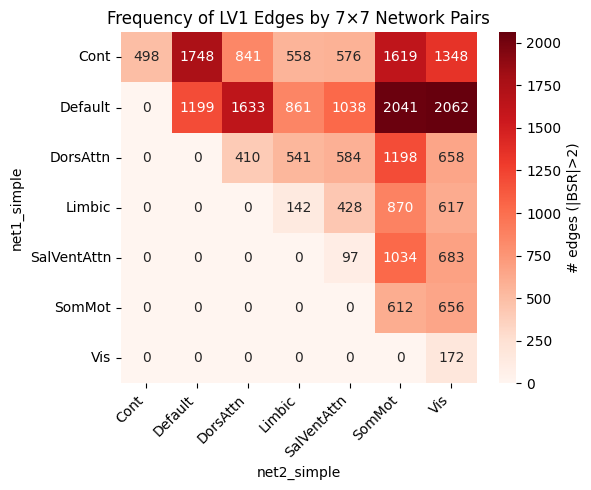

In [1]:
# %% 
# 1) Imports & paths
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_dir    = r"C:\Users\c3371138\projects\data\raw\export"
results_dir = os.path.join(base_dir, 'Results', 'rest_pls')
mapping_dir = os.path.join(base_dir, 'data', 'atlasmapping')
output_dir  = os.path.join(base_dir, 'output')

# %% 
# 2) Load your fitted PLS model
with open(os.path.join(results_dir, 'pls_behavioral_model_cleanedXY.pkl'), 'rb') as f:
    pls2 = pickle.load(f)

# %% 
# 3) Pull out the LV1 bootstrap‐ratio vector
bsr1 = pls2.bootres.x_weights_normed[:, 0]   # shape = (n_edges,)

# %% 
# 4) Reconstruct which ROI‐pairs those edges correspond to
#    (must match exactly the mask you used originally)
n_edges = bsr1.size
# solve n_rois*(n_rois-1)/2 == n_edges:
n_rois = int((1 + np.sqrt(1 + 8*n_edges)) / 2)

tri_i, tri_j = np.triu_indices(n_rois, k=1)
mask = np.load(os.path.join(output_dir, 'original_edge_mask.npy'))  # boolean array of length n_edges

parcel1 = tri_i[mask]
parcel2 = tri_j[mask]

# %% 
# 5) Map each parcel to its 7‐network label
mapping_df = pd.read_csv(os.path.join(mapping_dir, 'CombinedMapping.csv'))
mapping_df.index = mapping_df['ParcelID'] - 1   # make it 0‑based

# take the 7‑network column
label7 = mapping_df['Label7']

net1 = label7.iloc[parcel1].str.split('_').str[2].values
net2 = label7.iloc[parcel2].str.split('_').str[2].values

# %% 
# 6) Build a long table and aggregate to get counts per network‐pair
df = pd.DataFrame({
    'net1': net1,
    'net2': net2,
    'bsr' : bsr1
})
# ignore sign: we just want frequency of |BSR|>2
df = df[np.abs(df['bsr']) > 2].copy()

# canonicalize order so “A–B” == “B–A”
df['pair'] = df.apply(lambda r: tuple(sorted([r.net1, r.net2])), axis=1)

network_summary_7 = (
    df.groupby('pair')
      .size()
      .reset_index(name='edge_count')
)
network_summary_7[['net1_simple','net2_simple']] = pd.DataFrame(
    network_summary_7['pair'].tolist(), 
    index=network_summary_7.index
)

# %% 
# 7) Pivot into a matrix & plot your heatmap
cnt_matrix = network_summary_7.pivot(
    index='net1_simple',
    columns='net2_simple',
    values='edge_count'
).fillna(0)

plt.figure(figsize=(6,5))
sns.heatmap(cnt_matrix, annot=True, fmt='.0f', cmap='Reds', cbar_kws={'label':'# edges (|BSR|>2)'})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Frequency of LV1 Edges by 7×7 Network Pairs')
plt.tight_layout()
plt.show()


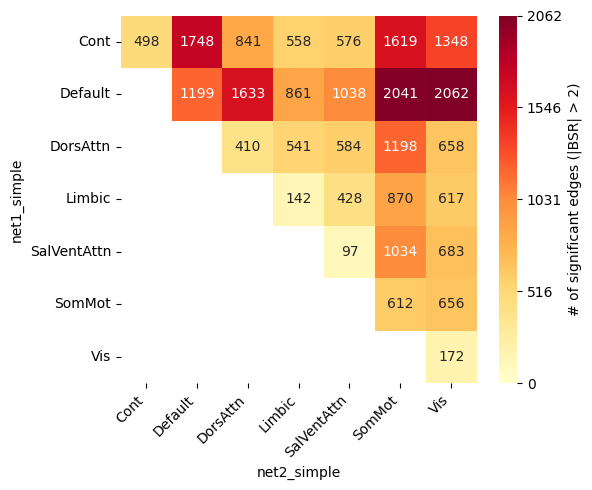

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# cnt_matrix is your 7×7 DataFrame of edge‐counts
# make sure it's square and ordered the way you want

# 1) Create a mask for the lower triangle (below the diagonal)
mask = np.tril(np.ones_like(cnt_matrix, dtype=bool), k=-1)

plt.figure(figsize=(6,5))
sns.heatmap(
    cnt_matrix,
    mask=mask,
    annot=True,
    fmt=".0f",            # no decimals
    cmap="YlOrRd",
    vmin=0,
    cbar_kws={
        'label': '# of significant edges (|BSR| > 2)',
        'ticks': np.linspace(0, cnt_matrix.values.max(), 5)
    }
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
# ↳ note: no plt.title() here, so the title is gone
plt.show()



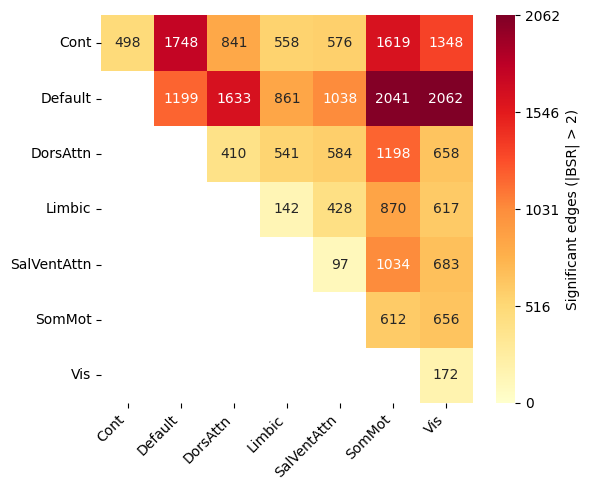

In [4]:
mask = np.tril(np.ones_like(cnt_matrix, dtype=bool), k=-1)

plt.figure(figsize=(6,5))
ax = sns.heatmap(
    cnt_matrix,
    mask=mask,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    vmin=0,
    cbar_kws={
        'label': 'Significant edges (|BSR| > 2)',
        'ticks': np.linspace(0, cnt_matrix.values.max(), 5)
    }
)

# rotate tick labels
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# remove the axis titles
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.show()
